In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import joblib

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (81412, 46)
X_test  : (20354, 46)
y_train : (81412,)
y_test  : (20354,)


In [5]:
print("Missing values in X_train :", X_train.isnull().sum().sum())
print("Missing values in X_test  :", X_test.isnull().sum().sum())

Missing values in X_train : 0
Missing values in X_test  : 0


In [6]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [7]:
print("X_train after SMOTE :", X_train_smote.shape)

print("\nClass Distribution")

print(y_train_smote.value_counts())

X_train after SMOTE : (144652, 46)

Class Distribution
readmitted
0    72326
1    72326
Name: count, dtype: int64


In [8]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
lr_pred = lr.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [10]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.6494546526481282


In [11]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.90      0.68      0.77     18083
           1       0.14      0.41      0.21      2271

    accuracy                           0.65     20354
   macro avg       0.52      0.55      0.49     20354
weighted avg       0.82      0.65      0.71     20354



In [12]:
print(confusion_matrix(y_test, lr_pred))

[[12277  5806]
 [ 1329   942]]


In [13]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_smote,
    y_train_smote
)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [14]:
dt_pred = dt.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [15]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.7199567652549868


In [16]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83     18083
           1       0.13      0.27      0.18      2271

    accuracy                           0.72     20354
   macro avg       0.51      0.53      0.51     20354
weighted avg       0.81      0.72      0.76     20354



In [17]:
print(confusion_matrix(y_test, dt_pred))

[[14031  4052]
 [ 1648   623]]


In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [19]:
rf_pred = rf.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [20]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.8280927581802103


In [21]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     18083
           1       0.17      0.14      0.15      2271

    accuracy                           0.83     20354
   macro avg       0.53      0.53      0.53     20354
weighted avg       0.81      0.83      0.82     20354



In [22]:
print(confusion_matrix(y_test, rf_pred))

[[16537  1546]
 [ 1953   318]]


In [23]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [24]:
xgb_pred = xgb.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [25]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy :", xgb_accuracy)

XGBoost Accuracy : 0.8194458091775573


In [26]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     18083
           1       0.18      0.17      0.18      2271

    accuracy                           0.82     20354
   macro avg       0.54      0.54      0.54     20354
weighted avg       0.82      0.82      0.82     20354



In [27]:
print(confusion_matrix(y_test, xgb_pred))

[[16289  1794]
 [ 1881   390]]


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
2,Random Forest,0.828093
3,XGBoost,0.819446
1,Decision Tree,0.719957
0,Logistic Regression,0.649455


In [29]:
joblib.dump(lr, "logistic_regression.pkl")
joblib.dump(dt, "decision_tree.pkl")
joblib.dump(rf, "random_forest.pkl")
joblib.dump(xgb, "xgboost.pkl")

print("All models saved successfully!")

All models saved successfully!


In [30]:
import os

print(os.listdir())

['.config', 'y_test.csv', 'logistic_regression.pkl', 'X_train.csv', 'y_train.csv', 'xgboost.pkl', 'X_test.csv', 'random_forest.pkl', 'decision_tree.pkl', 'sample_data']


In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
2,Random Forest,0.828093
3,XGBoost,0.819446
1,Decision Tree,0.719957
0,Logistic Regression,0.649455


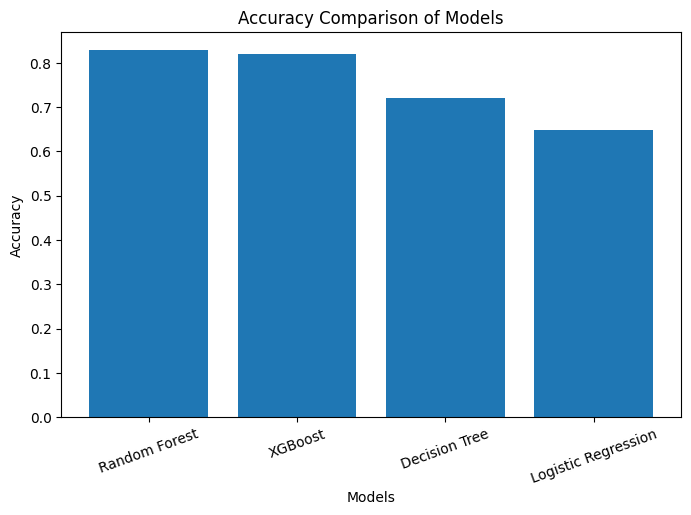

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

evaluation = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

evaluation

,Model,Precision,Recall,F1-Score
0,Logistic Regression,0.139597,0.414795,0.208892
1,Decision Tree,0.133262,0.274328,0.179384
2,Random Forest,0.170601,0.140026,0.153809
3,XGBoost,0.178571,0.171731,0.175084


In [34]:
best_model = comparison.iloc[0]

print("Best Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"] * 100, 2), "%")

Best Model : Random Forest
Accuracy : 82.81 %


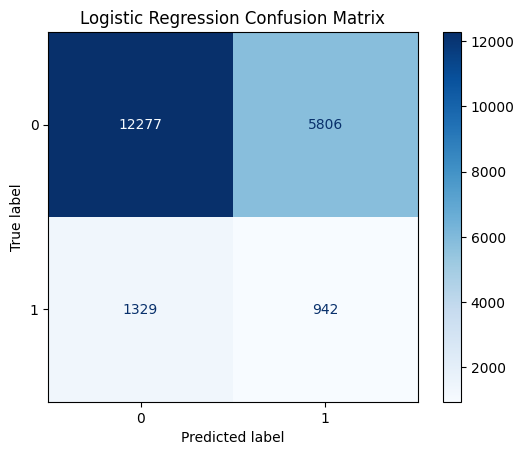

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

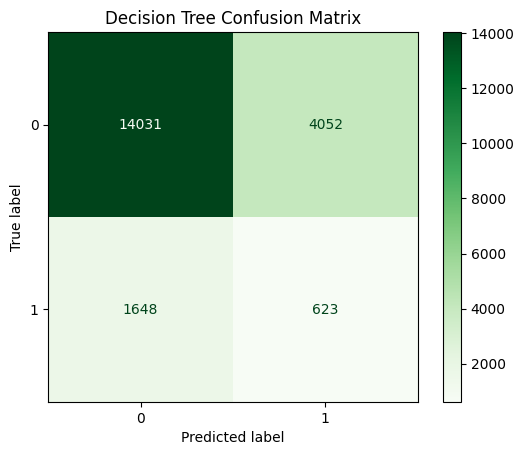

In [36]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

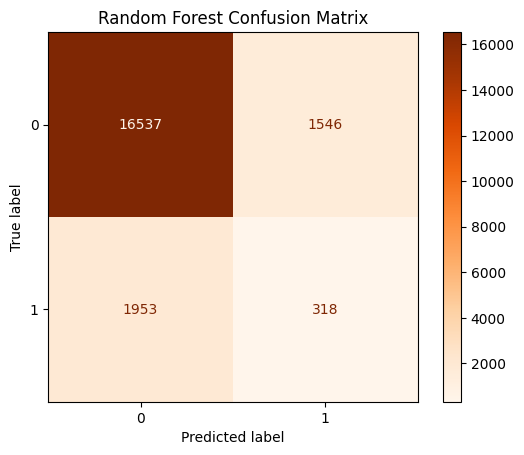

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

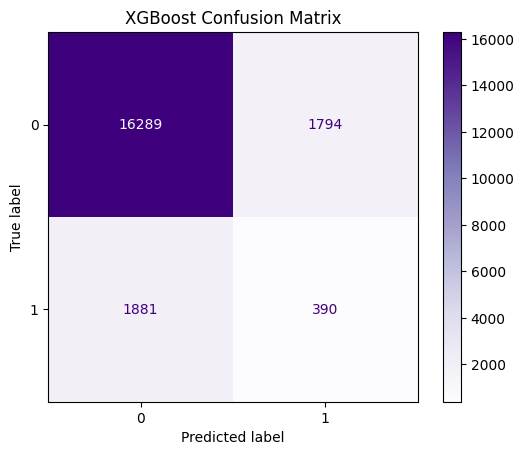

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    cmap="Purples"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_prob = lr.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]

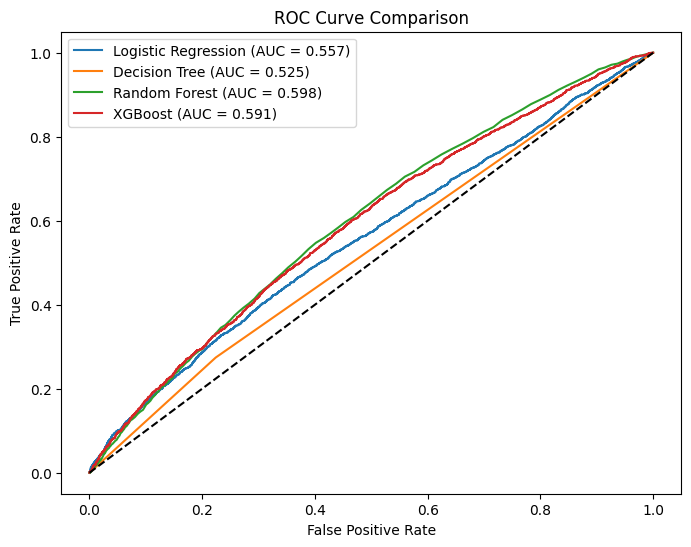

In [40]:
plt.figure(figsize=(8,6))

models = [
    ("Logistic Regression", lr_prob),
    ("Decision Tree", dt_prob),
    ("Random Forest", rf_prob),
    ("XGBoost", xgb_prob)
]

for name, prob in models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [41]:
comparison

,Model,Accuracy
2,Random Forest,0.828093
3,XGBoost,0.819446
1,Decision Tree,0.719957
0,Logistic Regression,0.649455


In [42]:
print("Final Project Conclusion")
print("-"*50)

print("1. Four machine learning models were trained and evaluated.")
print("2. Random Forest achieved the highest accuracy.")
print("3. Random Forest is selected as the final model.")
print("4. The model can help identify patients at risk of hospital readmission.")
print("5. This can support hospitals in improving patient care and reducing unnecessary readmissions.")

Final Project Conclusion
--------------------------------------------------
1. Four machine learning models were trained and evaluated.
2. Random Forest achieved the highest accuracy.
3. Random Forest is selected as the final model.
4. The model can help identify patients at risk of hospital readmission.
5. This can support hospitals in improving patient care and reducing unnecessary readmissions.


In [43]:
comparison.to_csv("Model_Comparison.csv", index=False)

print("Model Comparison Saved Successfully!")

Model Comparison Saved Successfully!


In [44]:
evaluation.to_csv("Evaluation_Metrics.csv", index=False)

print("Evaluation Metrics Saved Successfully!")

Evaluation Metrics Saved Successfully!
